<a href="https://colab.research.google.com/github/ricardosilva-boop/Research-Projects/blob/main/CNN_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === 1. Importar bibliotecas ===
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from scipy.spatial import ConvexHull, Delaunay
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

In [ ]:
# === 2. Ler dados ===
df = pd.read_csv("Cu_Mo_processed.csv")
coords = df[["X", "Y", "Z"]].values
mo = df["Mo"].values
cu = df["Cu"].values

In [ ]:
# === 3. Definir grade 3D ===
CELL_X, CELL_Y, CELL_Z = 25, 25, 25
PADDING = 0.2
(xmin, ymin, zmin), (xmax, ymax, zmax) = coords.min(0), coords.max(0)
xg = np.arange(xmin - PADDING*(xmax-xmin), xmax + CELL_X, CELL_X)
yg = np.arange(ymin - PADDING*(ymax-ymin), ymax + CELL_Y, CELL_Y)
zg = np.arange(zmin - PADDING*(zmax-zmin), zmax + CELL_Z, CELL_Z)
XX, YY, ZZ = np.meshgrid(xg, yg, zg, indexing='ij')

In [ ]:
# === 4. Normalizar e interpolar ===
scaler = MinMaxScaler()
scaled = scaler.fit_transform(np.column_stack([mo, cu]))
volume = np.zeros((len(xg), len(yg), len(zg), 2))
for i in range(2):
    grid = griddata(coords, scaled[:, i], (XX, YY, ZZ), method='nearest')
    volume[..., i] = grid

In [ ]:
# === 5. Criar patches de entrada ===
X_train, y_train = [], []
for i in range(len(df)):
    x, y, z = df.loc[i, ["X", "Y", "Z"]]
    ix = np.argmin(np.abs(xg - x))
    iy = np.argmin(np.abs(yg - y))
    iz = np.argmin(np.abs(zg - z))
    patch = volume[ix-1:ix+2, iy-1:iy+2, iz-1:iz+2, :]
    if patch.shape == (3,3,3,2):
        X_train.append(patch)
        y_train.append(mo[i])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
# === 6. Definir modelo CNN-3D ===
def build_cnn3d(input_shape):
    model = models.Sequential([
        layers.Conv3D(32, (3,3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling3D((2,2,2)),
        layers.Conv3D(64, (3,3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling3D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_cnn3d((3,3,3,2))
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.2736 - val_loss: 1.6363
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1460 - val_loss: 0.9797
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5797 - val_loss: 0.2132
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1177 - val_loss: 0.0664
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0770 - val_loss: 0.0607
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0695 - val_loss: 0.0565
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0626 - val_loss: 0.0552
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0631 - val_loss: 0.0533
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0622 - val_loss: 0.0529
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0748 - val_loss: 0.0533
Epoch 11/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0620 - val_loss: 0.0499
Epoch 12/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0705 - val_loss: 0.0489

In [ ]:
# === 7. Estimar nos blocos com inferência em lote ===
grid_pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])
hull = ConvexHull(coords)
mask = Delaunay(coords[hull.vertices]).find_simplex(grid_pts) >= 0
masked_pts = grid_pts[mask]

start = time.time()
valid_patches = []
valid_indices = []

for i, pt in enumerate(masked_pts):
    ix = np.argmin(np.abs(xg - pt[0]))
    iy = np.argmin(np.abs(yg - pt[1]))
    iz = np.argmin(np.abs(zg - pt[2]))
    patch = volume[ix-1:ix+2, iy-1:iy+2, iz-1:iz+2, :]
    if patch.shape == (3,3,3,2):
        valid_patches.append(patch)
        valid_indices.append(i)

valid_patches = np.array(valid_patches)
preds = model.predict(valid_patches, batch_size=64)
mo_pred_opt = np.full(len(masked_pts), np.nan)
mo_pred_opt[valid_indices] = preds[:,0]
end = time.time()
print(f"⏱️ Tempo de estimativa CNN-3D: {end - start:.2f} segundos")

4197/4197 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
⏱️ Tempo de estimativa CNN-3D: 21.74 segundos


In [ ]:
# Aplicar exponencial diretamente (sem correção de viés)
mo_pred_exp = np.exp(mo_pred_opt)

# Criar DataFrame com valores originais
df_blocks_cnn = pd.DataFrame({
    "Xc": masked_pts[:, 0],
    "Yc": masked_pts[:, 1],
    "Zc": masked_pts[:, 2],
    "Mo_est_CNN_log": mo_pred_opt,
    "Mo_est_CNN_exp": mo_pred_exp
})

# Salvar CSV
df_blocks_cnn.to_csv("modelo_blocos_CNN_2_2.csv", index=False)
print("✅ Modelo de blocos com CNN-3D salvo na escala original.")

✅ Modelo de blocos com CNN-3D salvo na escala original.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

In [ ]:
# === 1. Carregar dados ===
df_blocos = pd.read_csv("cnn_3d_var_log.csv")
df_furos = pd.read_csv("Cu_Mo.csv")

In [ ]:
# === 2. Associar furos aos blocos mais próximos ===
tree_blocos = cKDTree(df_blocos[["Xc", "Yc", "Zc"]].values)
furos_coords = df_furos[["X_coord", "Y_coord", "Z_coord"]].values
idx_nearest = tree_blocos.query(furos_coords, k=1)[1]

In [ ]:
# === 3. Comparar estimativas com valores reais ===
mo_real_log = np.log(df_furos["Mo"].values)
mo_est_log = df_blocos.iloc[idx_nearest]["Mo_est_CNN_log"].values
var_log = df_blocos.iloc[idx_nearest]["Var_log"].values  # se não existir, use média
if "Var_log" not in df_blocos.columns:
    var_log = np.full_like(mo_est_log, df_blocos["Mo_est_CNN_log"].var())

mo_real_orig = np.exp(mo_real_log)
mo_est_orig = np.exp(mo_est_log + 0.5 * var_log)

In [ ]:
# === 4. Métricas ===
resid_log = mo_real_log - mo_est_log
rmse_log = np.sqrt(np.mean(resid_log**2))
me_log = np.mean(resid_log)
corr_log = np.corrcoef(mo_real_log, mo_est_log)[0, 1]

resid_orig = mo_real_orig - mo_est_orig
rmse_orig = np.sqrt(np.mean(resid_orig**2))
me_orig = np.mean(resid_orig)
corr_orig = np.corrcoef(mo_real_orig, mo_est_orig)[0, 1]

In [ ]:
print("\n=== MÉTRICAS DO MODELO DE BLOCO CNN_3D ===")
print(f"[LOG]      RMSE: {rmse_log:.4f} | ME: {me_log:.4f} | Corr: {corr_log:.4f}")
print(f"[ORIGINAL] RMSE: {rmse_orig:.4f} | ME: {me_orig:.4f} | Corr: {corr_orig:.4f}")


=== MÉTRICAS DO MODELO DE BLOCO CNN_3D ===
[LOG]      RMSE: 0.2573 | ME: 0.0966 | Corr: 0.8836
[ORIGINAL] RMSE: 0.0294 | ME: 0.0042 | Corr: 0.7831


In [ ]:
# === 5. Calcular R-quadrado ===
r2_log = r2_score(mo_real_log, mo_est_log)
r2_orig = r2_score(mo_real_orig, mo_est_orig)

print(f"[LOG]      R2: {r2_log:.4f}")
print(f"[ORIGINAL] R2: {r2_orig:.4f}")

[LOG]      R2: 0.7447
[ORIGINAL] R2: 0.5912


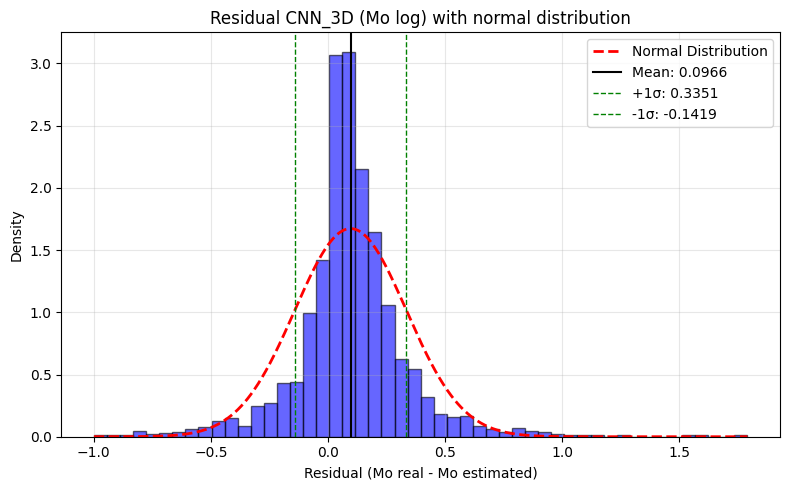

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# === 1. Estatísticas dos resíduos log ===
mu_log = np.mean(resid_log)
sigma_log = np.std(resid_log)

# === 2. Histograma com curva normal ===
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(resid_log, bins=50, density=True, color='blue', edgecolor='k', alpha=0.6)

# Curva normal teórica
x = np.linspace(min(resid_log), max(resid_log), 1000)
plt.plot(x, norm.pdf(x, mu_log, sigma_log), 'r--', linewidth=2, label='Normal Distribution')

# Linhas de média e desvio padrão
plt.axvline(mu_log, color='black', linestyle='-', linewidth=1.5, label=f'Mean: {mu_log:.4f}')
plt.axvline(mu_log + sigma_log, color='green', linestyle='--', linewidth=1, label=f'+1σ: {mu_log + sigma_log:.4f}')
plt.axvline(mu_log - sigma_log, color='green', linestyle='--', linewidth=1, label=f'-1σ: {mu_log - sigma_log:.4f}')

# Estética
plt.title("Residual CNN_3D (Mo log) with normal distribution")
plt.xlabel("Residual (Mo real - Mo estimated)")
plt.ylabel("Density")
plt.legend(loc='upper right') # Placing legend inside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Residual_CNN_3D_Mo_log_ND_legend_inside.pdf", bbox_inches="tight", format="pdf")
plt.show()


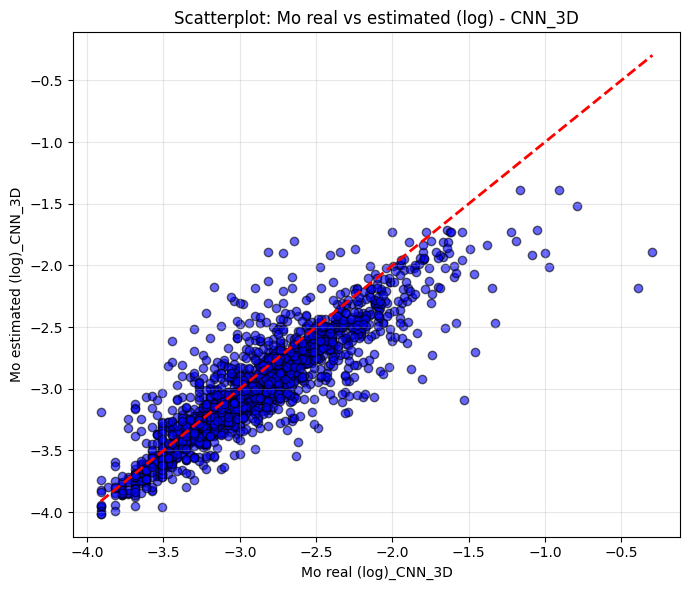

In [ ]:
# === 7. Dispersão real vs estimado (original) ===
plt.figure(figsize=(7,6))
plt.scatter(mo_real_log, mo_est_log, color='blue', alpha=0.6, edgecolor='k')
plt.plot([mo_real_log.min(), mo_real_log.max()], [mo_real_log.min(), mo_real_log.max()], 'r--', lw=2)
plt.xlabel("Mo real (log)_CNN_3D")
plt.ylabel("Mo estimated (log)_CNN_3D")
plt.title("Scatterplot: Mo real vs estimated (log) - CNN_3D")
plt.savefig("scatterplot_Mo real vs estimated (log)_CNN_3D.pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

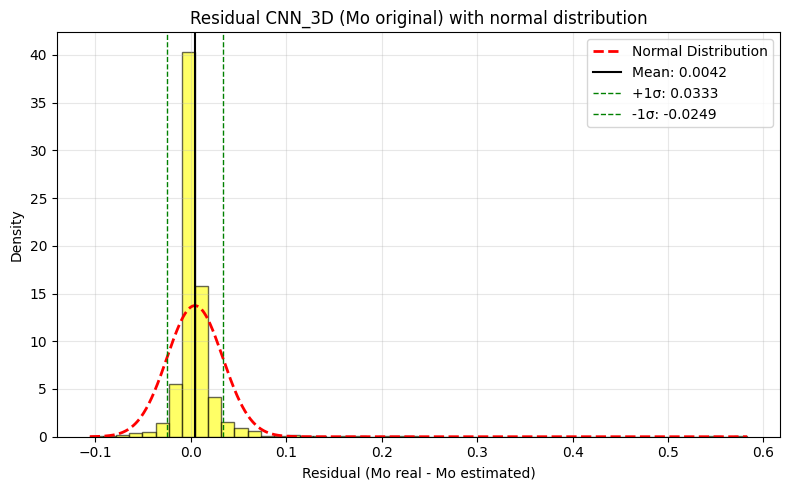

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# === Estatísticas básicas ===
mu = np.mean(resid_orig)
sigma = np.std(resid_orig)

# === Histograma com curva normal ===
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(resid_orig, bins=50, density=True, color='yellow', edgecolor='k', alpha=0.6)

# Curva normal teórica
x = np.linspace(min(resid_orig), max(resid_orig), 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Normal Distribution')

# Linhas de média e desvio padrão
plt.axvline(mu, color='black', linestyle='-', linewidth=1.5, label=f'Mean: {mu:.4f}')
plt.axvline(mu + sigma, color='green', linestyle='--', linewidth=1, label=f'+1σ: {mu+sigma:.4f}')
plt.axvline(mu - sigma, color='green', linestyle='--', linewidth=1, label=f'-1σ: {mu-sigma:.4f}')

# Estética
plt.title("Residual CNN_3D (Mo original) with normal distribution")
plt.xlabel("Residual (Mo real - Mo estimated)")
plt.ylabel("Density")
plt.legend(loc='upper right') # Placing legend inside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Residual_CNN_3D_Mo_original_ND_legend_inside.pdf", bbox_inches="tight", format="pdf")
plt.show()


In [ ]:
# === 6. Calcular coeficiente de assimetria e curtose ===
from scipy.stats import skew, kurtosis

skew_log = skew(resid_log)
kurtosis_log = kurtosis(resid_log)

skew_orig = skew(resid_orig)
kurtosis_orig = kurtosis(resid_orig)

print("\n=== ASSIMETRIA E CURTOSE DOS RESÍDUOS ===")
print(f"[LOG]      Assimetria: {skew_log:.4f} | Curtose: {kurtosis_log:.4f}")
print(f"[ORIGINAL] Assimetria: {skew_orig:.4f} | Curtose: {kurtosis_orig:.4f}")


=== ASSIMETRIA E CURTOSE DOS RESÍDUOS ===
[LOG]      Assimetria: 0.4656 | Curtose: 5.8790
[ORIGINAL] Assimetria: 9.6105 | Curtose: 166.5242


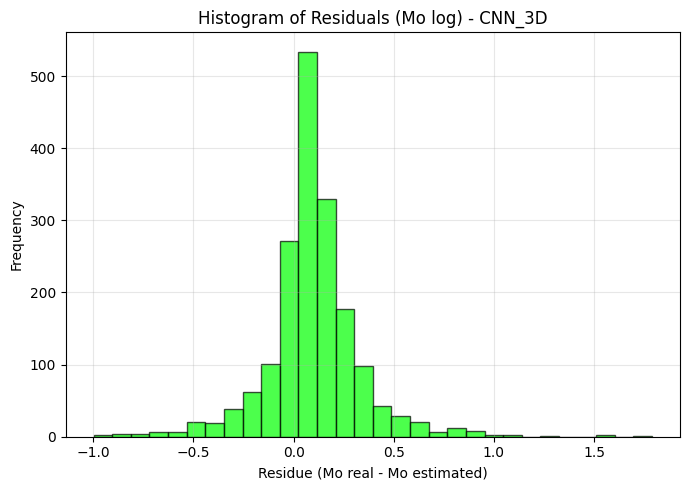

In [ ]:
# === 5. Histograma dos resíduos (log) ===
plt.figure(figsize=(7,5))
plt.hist(resid_log, bins=30, color='lime', edgecolor='k', alpha=0.7)
plt.title("Histogram of Residuals (Mo log) - CNN_3D")
plt.xlabel("Residue (Mo real - Mo estimated)")
plt.ylabel("Frequency")
plt.savefig("histogram_residuals_Mo_log_CNN_3D.pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

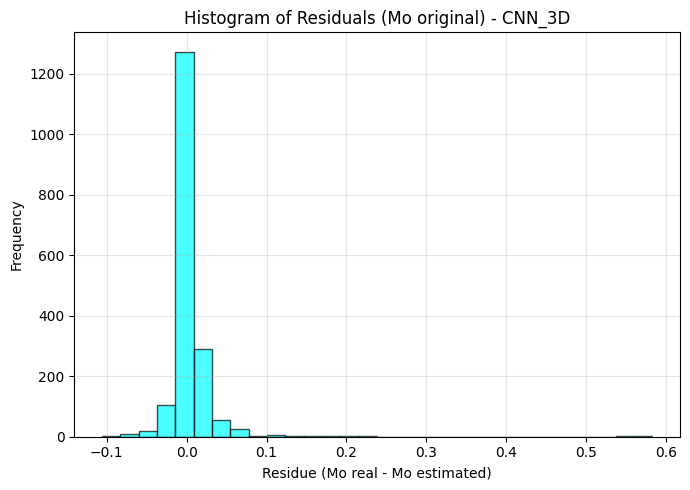

In [ ]:
# === 5. Histograma dos resíduos (original) ===
plt.figure(figsize=(7,5))
plt.hist(resid_orig, bins=30, color='cyan', edgecolor='k', alpha=0.7)
plt.title("Histogram of Residuals (Mo original) - CNN_3D")
plt.xlabel("Residue (Mo real - Mo estimated)")
plt.ylabel("Frequency")
plt.savefig("histogram_residuals_Mo_original_CNN_3D.pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

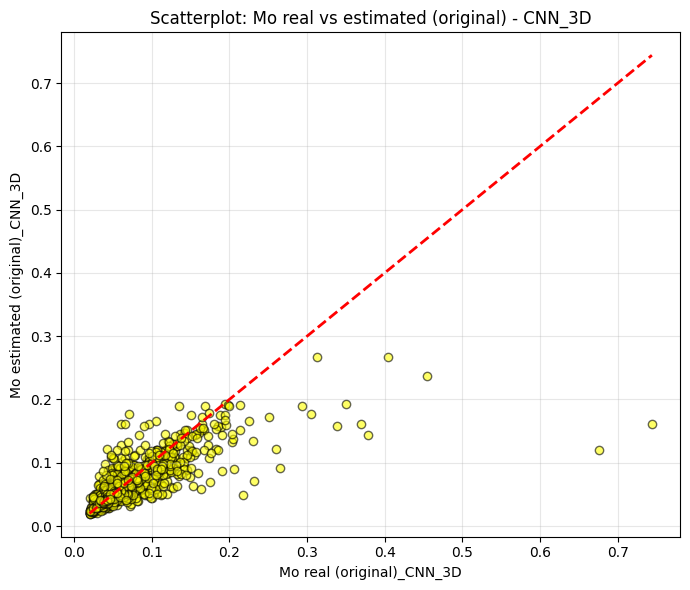

In [ ]:
# === 7. Dispersão real vs estimado (original) ===
plt.figure(figsize=(7,6))
plt.scatter(mo_real_orig, mo_est_orig, color='yellow', alpha=0.6, edgecolor='k')
plt.plot([mo_real_orig.min(), mo_real_orig.max()], [mo_real_orig.min(), mo_real_orig.max()], 'r--', lw=2)
plt.xlabel("Mo real (original)_CNN_3D")
plt.ylabel("Mo estimated (original)_CNN_3D")
plt.title("Scatterplot: Mo real vs estimated (original) - CNN_3D")
plt.savefig("scatterplot_Mo real vs estimated (original)_CNN_3D.pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()